# NY Yellow Taxi Trip vs Weather Analysis
This notebook compares the Yellow Taxi Ride against the Weather to see if any relation could be found. _Data only for January 2026 is compared_. 

### Source of data 
_New York Taxi Trips_ data for yellow taxis was downloaded from: 
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
The column names description can be found in yellow taxi data dictionary:
https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf
```
curl https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet --output yellow_tripdata_2026-01.parquet
```


The _Daily Weather Data for New York Wallstreet Station_ was downloaded from:
https://dev.meteostat.net/data/timeseries/daily
The station ID can be found in the full dump:
https://github.com/meteostat/weather-stations
The column names description can be found in meteorological documentation page:
https://dev.meteostat.net/parameters?g=daily&d=1
To get New York Wallstreet Station (KJRB0):
```
curl https://data.meteostat.net/daily/2026/KJRB0.csv.gz --output new_york_weather_daily_2026.csv.gz
```


In [0]:
%load_ext autoreload
%autoreload 2
# Enables autoreload; learn more at https://docs.databricks.com/en/files/workspace-modules.html#autoreload-for-python-modules
# To disable autoreload; run %autoreload 0

In [0]:
dbutils.widgets.dropdown("debug_mode", "False", ["True", "False"])  # noqa
DEBUG = dbutils.widgets.get("debug_mode") == "True"  # noqa
print(f"Debug mode: {DEBUG}")

Debug mode: True


## Imports

In [0]:
from datetime import datetime

import matplotlib.pyplot as plt
import yaml
from pyspark.sql import functions as F

from repository.spark_repo import SparkRepository
from schemas.input_schema import NEW_YORK_WEATHER_SCHEMA
from transformations.data_cleaning import (
    quarantine_date_range,
    quarantine_negative_values,
    quarantine_null_values,
    timestamp_normalization,
)
from utils.constants import ISO_DATE_FORMAT

## Local Constants

In [0]:
# Range constants
# Datetime Range = [_MIN_DATETIME, _MAX_DATETIME)
_MIN_DATETIME = datetime(2026, 1, 1)
_MAX_DATETIME = datetime(2026, 2, 1)  # datetime to be excluded in the range
# Timezone
_NEW_YORK_TIMEZONE = "America/New_York"

## Load Input Data

In [0]:
try:
    with open("pipeline_config.yaml") as f:
        config = yaml.safe_load(f)
except Exception as e:
    print(f"Error loading config file: {e}")
print(config)

{'pipeline_name': 'taxi_weather_analysis', 'ny_yellow_taxi': {'type': 'parquet', 'path': '/Volumes/dbw_schwarz_test/default/temp/bronze/yellow_tripdata_2026-01.parquet', 'path_type': 'unity_catalog'}, 'ny_weather': {'type': 'csv', 'path': '/Volumes/dbw_schwarz_test/default/temp/bronze/new_york_weather_daily_2026.csv', 'path_type': 'unity_catalog'}}


### Load Yellow Taxi Ride Data

In [0]:
taxi_raw_data = SparkRepository(spark).read(  # noqa
    path=config.get("ny_yellow_taxi").get("path"), file_format="parquet"
)

if DEBUG:
    print(f"Number of rows in taxi_raw_data: {taxi_raw_data.count()}")
    display(taxi_raw_data.limit(10))

Number of rows in taxi_raw_data: 3724889


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2,2026-01-01T00:54:04.000,2026-01-01T00:59:37.000,1,0.97,1,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0
1,2026-01-01T00:34:04.000,2026-01-01T00:39:47.000,0,0.9,1,N,163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75
1,2026-01-01T00:57:06.000,2026-01-01T01:05:59.000,0,1.4,1,N,43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75
2,2026-01-01T00:15:22.000,2026-01-01T00:58:10.000,4,5.58,1,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2026-01-01T00:27:13.000,2026-01-01T00:40:43.000,0,2.16,1,N,88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75
2,2026-01-01T00:47:11.000,2026-01-01T01:00:47.000,2,2.33,1,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2026-01-01T00:17:54.000,2026-01-01T00:28:32.000,1,1.3,1,N,142,50,2,11.4,4.25,0.5,0.0,0.0,1.0,17.15,2.5,0.0,0.75
1,2026-01-01T00:34:28.000,2026-01-01T00:59:05.000,0,2.9,1,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.0,2.5,0.0,0.75
2,2026-01-01T00:34:14.000,2026-01-01T01:11:58.000,1,5.34,1,N,161,45,1,37.3,1.0,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
2,2026-01-01T00:41:07.000,2026-01-01T00:50:42.000,3,1.83,1,N,237,263,1,10.7,1.0,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.0


### Load Weather Data for New York Wallstreet

In [0]:
weather_raw_data = SparkRepository(spark).read(  # noqa
    path=config.get("ny_weather").get("path"),
    file_format="csv",
    header=True,
    schema=NEW_YORK_WEATHER_SCHEMA,
)

if DEBUG:
    print(f"Number of rows in weather_raw_data: {weather_raw_data.count()}")
    display(weather_raw_data.limit(10))

Number of rows in weather_raw_data: 208


year,month,day,temp,temp_source,tmin,tmin_source,tmax,tmax_source,rhum,rhum_source,prcp,prcp_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source
2026,1,1,-0.8,metar,-4.0,metar,3.0,metar,56,metar,0.4,metno_forecast metar,13.6,metar,1007.9,metar,3,metar metno_forecast
2026,1,2,-2.6,metar,-5.0,metar,-1.0,metar,70,metar,0.0,metno_forecast metar,16.3,metar,1010.4,metar,6,metar metno_forecast
2026,1,3,-1.6,metar,-4.0,metar,0.0,metar,54,metar,0.0,metno_forecast,10.0,metar,1015.3,metar,5,metno_forecast metar
2026,1,4,0.2,metar,-2.0,metar,3.0,metar,64,metar,0.0,metno_forecast metar,7.2,metar,1019.1,metar,5,metar metno_forecast
2026,1,5,1.0,metar,-1.0,metar,3.0,metar,73,metar,0.0,metno_forecast,11.5,metar,1021.4,metar,6,metar metno_forecast
2026,1,6,3.9,metar,2.0,metar,6.0,metar,87,metar metno_forecast,0.0,metno_forecast metar,11.5,metar,1012.9,metar,7,metno_forecast metar
2026,1,7,6.6,metar,3.0,metar,11.0,metar,82,metar metno_forecast,0.0,metno_forecast metar,8.2,metar,1008.9,metar,7,metar metno_forecast
2026,1,8,8.0,metar,6.0,metar,12.0,metar,67,metar,0.0,metno_forecast,4.6,metar,1022.5,metar,3,metno_forecast metar
2026,1,9,8.3,metar,6.0,metar,11.0,metar,94,metar metno_forecast,0.0,metno_forecast metar,7.5,metar,1022.9,metar,5,metar metno_forecast
2026,1,10,6.8,metar,5.0,metar,10.0,metar,87,metno_forecast metar,0.1,metno_forecast metar,13.1,metar,1018.6,metar,7,metar metno_forecast


## Clean Input Data

### Cleaning taxi data

In [0]:
taxi_wo_null, taxi_q_null = quarantine_null_values(taxi_raw_data, taxi_raw_data.columns)

if DEBUG:
    display(taxi_wo_null.limit(10))
    display(taxi_q_null.limit(10))
    print(f"Number of rows in taxi_wo_null: {taxi_wo_null.count()}")
    print(f"Number of rows in taxi_q: {taxi_q_null.count()}")

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2,2026-01-01T00:54:04.000,2026-01-01T00:59:37.000,1,0.97,1,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0
1,2026-01-01T00:34:04.000,2026-01-01T00:39:47.000,0,0.9,1,N,163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75
1,2026-01-01T00:57:06.000,2026-01-01T01:05:59.000,0,1.4,1,N,43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75
2,2026-01-01T00:15:22.000,2026-01-01T00:58:10.000,4,5.58,1,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2026-01-01T00:27:13.000,2026-01-01T00:40:43.000,0,2.16,1,N,88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75
2,2026-01-01T00:47:11.000,2026-01-01T01:00:47.000,2,2.33,1,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2026-01-01T00:17:54.000,2026-01-01T00:28:32.000,1,1.3,1,N,142,50,2,11.4,4.25,0.5,0.0,0.0,1.0,17.15,2.5,0.0,0.75
1,2026-01-01T00:34:28.000,2026-01-01T00:59:05.000,0,2.9,1,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.0,2.5,0.0,0.75
2,2026-01-01T00:34:14.000,2026-01-01T01:11:58.000,1,5.34,1,N,161,45,1,37.3,1.0,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
2,2026-01-01T00:41:07.000,2026-01-01T00:50:42.000,3,1.83,1,N,237,263,1,10.7,1.0,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.0


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2,2026-01-01T00:28:47.000,2026-01-01T00:49:30.000,null,10.58,null,null,43,200,0,82.01,0.0,0.5,0.0,3.18,1.0,89.19,null,null,0.0
2,2026-01-01T00:54:24.000,2026-01-01T01:15:01.000,null,11.04,null,null,200,51,0,51.77,0.0,0.5,0.0,0.0,1.0,53.27,null,null,0.0
2,2026-01-01T00:12:31.000,2026-01-01T00:41:02.000,null,4.25,null,null,142,234,0,32.17,0.0,0.5,0.0,0.0,1.0,36.92,null,null,0.75
2,2026-01-01T00:48:56.000,2026-01-01T01:08:00.000,null,2.05,null,null,90,114,0,18.29,0.0,0.5,1.0,0.0,1.0,24.04,null,null,0.75
2,2026-01-01T00:32:09.000,2026-01-01T00:41:05.000,null,0.97,null,null,237,163,0,15.02,0.0,0.5,0.0,0.0,1.0,22.77,null,null,0.75
2,2026-01-01T00:24:17.000,2026-01-01T00:31:51.000,null,1.99,null,null,129,83,0,13.87,0.0,0.5,0.0,0.0,1.0,25.37,null,null,0.0
2,2026-01-01T00:49:31.000,2026-01-01T01:21:03.000,null,6.44,null,null,238,107,0,24.77,0.0,0.5,0.0,0.0,1.0,29.52,null,null,0.75
2,2026-01-01T00:39:35.000,2026-01-01T01:27:01.000,null,7.4,null,null,79,151,0,59.36,0.0,0.5,0.0,0.0,1.0,76.93,null,null,0.75
2,2026-01-01T00:27:04.000,2026-01-01T00:36:03.000,null,0.98,null,null,114,79,0,9.87,0.0,0.5,0.0,0.0,1.0,14.62,null,null,0.75
2,2026-01-01T00:44:00.000,2026-01-01T01:08:00.000,null,4.3,null,null,75,50,0,33.59,0.0,0.5,0.0,0.0,1.0,44.09,null,null,0.75


Number of rows in taxi_wo_null: 2636831
Number of rows in taxi_q: 1088058


In [0]:
taxi_wo_negative, taxi_q_negative = quarantine_negative_values(
    taxi_wo_null,
    [
        "passenger_count",
        "trip_distance",
        "fare_amount",
        "extra",
        "mta_tax",
        "tip_amount",
        "tolls_amount",
        "improvement_surcharge",
        "total_amount",
        "congestion_surcharge",
        "Airport_fee",
        "cbd_congestion_fee",
    ],
)

if DEBUG:
    display(taxi_wo_negative.limit(10))
    display(taxi_q_negative.limit(10))
    print(f"Number of rows in taxi_wo_negative: {taxi_wo_negative.count()}")
    print(f"Number of rows in taxi_q_negative: {taxi_q_negative.count()}")

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2,2026-01-01T00:54:04.000,2026-01-01T00:59:37.000,1,0.97,1,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0
1,2026-01-01T00:34:04.000,2026-01-01T00:39:47.000,0,0.9,1,N,163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75
1,2026-01-01T00:57:06.000,2026-01-01T01:05:59.000,0,1.4,1,N,43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75
2,2026-01-01T00:15:22.000,2026-01-01T00:58:10.000,4,5.58,1,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2026-01-01T00:27:13.000,2026-01-01T00:40:43.000,0,2.16,1,N,88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75
2,2026-01-01T00:47:11.000,2026-01-01T01:00:47.000,2,2.33,1,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2026-01-01T00:17:54.000,2026-01-01T00:28:32.000,1,1.3,1,N,142,50,2,11.4,4.25,0.5,0.0,0.0,1.0,17.15,2.5,0.0,0.75
1,2026-01-01T00:34:28.000,2026-01-01T00:59:05.000,0,2.9,1,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.0,2.5,0.0,0.75
2,2026-01-01T00:34:14.000,2026-01-01T01:11:58.000,1,5.34,1,N,161,45,1,37.3,1.0,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
2,2026-01-01T00:41:07.000,2026-01-01T00:50:42.000,3,1.83,1,N,237,263,1,10.7,1.0,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.0


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2,2026-01-01T00:54:05.000,2026-01-01T00:56:36.000,1,0.63,1,N,143,143,4,-5.1,-1.0,-0.5,0.0,0.0,-1.0,-10.1,-2.5,0.0,0.0
2,2026-01-01T00:43:29.000,2026-01-01T01:09:26.000,1,1.92,1,N,170,79,4,-22.6,-1.0,-0.5,0.0,0.0,-1.0,-28.35,-2.5,0.0,-0.75
2,2026-01-01T00:37:39.000,2026-01-01T00:38:17.000,1,0.02,1,N,261,261,4,-3.0,-1.0,-0.5,0.0,0.0,-1.0,-8.75,-2.5,0.0,-0.75
2,2026-01-01T00:01:24.000,2026-01-01T00:02:02.000,1,0.03,1,N,162,162,4,-3.0,-1.0,-0.5,0.0,0.0,-1.0,-8.75,-2.5,0.0,-0.75
2,2026-01-01T00:10:13.000,2026-01-01T00:35:15.000,3,3.12,1,N,161,263,2,-22.6,-1.0,-0.5,0.0,0.0,-1.0,-28.35,-2.5,0.0,-0.75
2,2026-01-01T00:33:23.000,2026-01-01T00:40:16.000,3,1.03,1,N,238,239,4,-8.6,-1.0,-0.5,0.0,0.0,-1.0,-13.6,-2.5,0.0,0.0
2,2025-12-31T23:57:29.000,2025-12-31T23:57:32.000,2,0.01,2,N,132,264,3,-70.0,0.0,-0.5,0.0,0.0,-1.0,-71.5,0.0,0.0,0.0
2,2026-01-01T00:01:52.000,2026-01-01T00:04:22.000,2,0.14,1,N,234,234,3,-3.7,-1.0,-0.5,0.0,0.0,-1.0,-9.45,-2.5,0.0,-0.75
2,2026-01-01T00:24:04.000,2026-01-01T00:36:44.000,1,3.63,1,N,263,168,2,-17.7,-1.0,-0.5,0.0,0.0,-1.0,-22.7,-2.5,0.0,0.0
2,2026-01-01T00:30:51.000,2026-01-01T00:31:00.000,1,0.01,1,N,239,239,4,-3.0,-1.0,-0.5,0.0,0.0,-1.0,-8.0,-2.5,0.0,0.0


Number of rows in taxi_wo_negative: 2596861
Number of rows in taxi_q_negative: 39970


In [0]:
taxi_fixed_pickup_datetime = timestamp_normalization(
    taxi_wo_negative, "tpep_pickup_datetime", _NEW_YORK_TIMEZONE, "pickup_datetime"
)
taxi_fixed_datetime = timestamp_normalization(
    taxi_fixed_pickup_datetime, "tpep_dropoff_datetime", _NEW_YORK_TIMEZONE, "dropoff_datetime"
)

if DEBUG:
    display(taxi_fixed_datetime.limit(10))

VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime_utc,pickup_datetime_local,dropoff_datetime_utc,dropoff_datetime_local
2,1,0.97,1,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0,2026-01-01T05:54:04.000Z,2026-01-01T00:54:04.000Z,2026-01-01T05:59:37.000Z,2026-01-01T00:59:37.000Z
1,0,0.9,1,N,163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75,2026-01-01T05:34:04.000Z,2026-01-01T00:34:04.000Z,2026-01-01T05:39:47.000Z,2026-01-01T00:39:47.000Z
1,0,1.4,1,N,43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75,2026-01-01T05:57:06.000Z,2026-01-01T00:57:06.000Z,2026-01-01T06:05:59.000Z,2026-01-01T01:05:59.000Z
2,4,5.58,1,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01T05:15:22.000Z,2026-01-01T00:15:22.000Z,2026-01-01T05:58:10.000Z,2026-01-01T00:58:10.000Z
2,0,2.16,1,N,88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75,2026-01-01T05:27:13.000Z,2026-01-01T00:27:13.000Z,2026-01-01T05:40:43.000Z,2026-01-01T00:40:43.000Z
2,2,2.33,1,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75,2026-01-01T05:47:11.000Z,2026-01-01T00:47:11.000Z,2026-01-01T06:00:47.000Z,2026-01-01T01:00:47.000Z
1,1,1.3,1,N,142,50,2,11.4,4.25,0.5,0.0,0.0,1.0,17.15,2.5,0.0,0.75,2026-01-01T05:17:54.000Z,2026-01-01T00:17:54.000Z,2026-01-01T05:28:32.000Z,2026-01-01T00:28:32.000Z
1,0,2.9,1,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.0,2.5,0.0,0.75,2026-01-01T05:34:28.000Z,2026-01-01T00:34:28.000Z,2026-01-01T05:59:05.000Z,2026-01-01T00:59:05.000Z
2,1,5.34,1,N,161,45,1,37.3,1.0,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75,2026-01-01T05:34:14.000Z,2026-01-01T00:34:14.000Z,2026-01-01T06:11:58.000Z,2026-01-01T01:11:58.000Z
2,3,1.83,1,N,237,263,1,10.7,1.0,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.0,2026-01-01T05:41:07.000Z,2026-01-01T00:41:07.000Z,2026-01-01T05:50:42.000Z,2026-01-01T00:50:42.000Z


In [0]:
taxi_valid_dates, taxi_date_invalid = quarantine_date_range(
    taxi_fixed_datetime, _MIN_DATETIME, _MAX_DATETIME, "pickup_datetime_local"
)

if DEBUG:
    display(taxi_valid_dates.limit(10))
    display(taxi_date_invalid.limit(10))
    print(f"Number of rows in taxi_valid_dates: {taxi_valid_dates.count()}")
    print(f"Number of rows in taxi_date_invalid: {taxi_date_invalid.count()}")

VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime_utc,pickup_datetime_local,dropoff_datetime_utc,dropoff_datetime_local
2,1,0.97,1,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0,2026-01-01T05:54:04.000Z,2026-01-01T00:54:04.000Z,2026-01-01T05:59:37.000Z,2026-01-01T00:59:37.000Z
1,0,0.9,1,N,163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75,2026-01-01T05:34:04.000Z,2026-01-01T00:34:04.000Z,2026-01-01T05:39:47.000Z,2026-01-01T00:39:47.000Z
1,0,1.4,1,N,43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75,2026-01-01T05:57:06.000Z,2026-01-01T00:57:06.000Z,2026-01-01T06:05:59.000Z,2026-01-01T01:05:59.000Z
2,4,5.58,1,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01T05:15:22.000Z,2026-01-01T00:15:22.000Z,2026-01-01T05:58:10.000Z,2026-01-01T00:58:10.000Z
2,0,2.16,1,N,88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75,2026-01-01T05:27:13.000Z,2026-01-01T00:27:13.000Z,2026-01-01T05:40:43.000Z,2026-01-01T00:40:43.000Z
2,2,2.33,1,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75,2026-01-01T05:47:11.000Z,2026-01-01T00:47:11.000Z,2026-01-01T06:00:47.000Z,2026-01-01T01:00:47.000Z
1,1,1.3,1,N,142,50,2,11.4,4.25,0.5,0.0,0.0,1.0,17.15,2.5,0.0,0.75,2026-01-01T05:17:54.000Z,2026-01-01T00:17:54.000Z,2026-01-01T05:28:32.000Z,2026-01-01T00:28:32.000Z
1,0,2.9,1,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.0,2.5,0.0,0.75,2026-01-01T05:34:28.000Z,2026-01-01T00:34:28.000Z,2026-01-01T05:59:05.000Z,2026-01-01T00:59:05.000Z
2,1,5.34,1,N,161,45,1,37.3,1.0,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75,2026-01-01T05:34:14.000Z,2026-01-01T00:34:14.000Z,2026-01-01T06:11:58.000Z,2026-01-01T01:11:58.000Z
2,3,1.83,1,N,237,263,1,10.7,1.0,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.0,2026-01-01T05:41:07.000Z,2026-01-01T00:41:07.000Z,2026-01-01T05:50:42.000Z,2026-01-01T00:50:42.000Z


VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime_utc,pickup_datetime_local,dropoff_datetime_utc,dropoff_datetime_local
2,2,0.01,2,N,132,264,3,70.0,0.0,0.5,0.0,0.0,1.0,71.5,0.0,0.0,0.0,2026-01-01T04:57:29.000Z,2025-12-31T23:57:29.000Z,2026-01-01T04:57:32.000Z,2025-12-31T23:57:32.000Z
2,2,40.14,3,N,132,1,2,167.2,1.0,0.0,0.0,27.0,1.0,198.7,0.0,1.75,0.75,2026-01-01T04:58:58.000Z,2025-12-31T23:58:58.000Z,2026-01-01T06:04:39.000Z,2026-01-01T01:04:39.000Z
2,1,2.0,1,N,164,144,1,12.8,1.0,0.5,2.0,0.0,1.0,20.55,2.5,0.0,0.75,2026-01-01T04:57:54.000Z,2025-12-31T23:57:54.000Z,2026-01-01T05:09:36.000Z,2026-01-01T00:09:36.000Z
2,1,0.43,1,N,163,48,2,14.9,1.0,0.5,0.0,0.0,1.0,20.65,2.5,0.0,0.75,2026-01-01T04:59:06.000Z,2025-12-31T23:59:06.000Z,2026-01-01T05:16:43.000Z,2026-01-01T00:16:43.000Z
2,1,1.68,1,N,113,4,1,10.7,1.0,0.5,2.0,0.0,1.0,18.45,2.5,0.0,0.75,2026-01-01T04:58:45.000Z,2025-12-31T23:58:45.000Z,2026-01-01T05:07:12.000Z,2026-01-01T00:07:12.000Z
2,1,1.78,1,N,79,249,1,15.6,1.0,0.5,5.34,0.0,1.0,26.69,2.5,0.0,0.75,2026-02-01T05:45:01.000Z,2026-02-01T00:45:01.000Z,2026-02-01T06:03:08.000Z,2026-02-01T01:03:08.000Z


Number of rows in taxi_valid_dates: 2596855
Number of rows in taxi_date_invalid: 6


Removing all the rows where passenger where 0

In [0]:
taxi_w_passengers = taxi_valid_dates.filter(F.col("passenger_count") > 0)

if DEBUG:
    display(taxi_w_passengers.limit(10))
    print(f"Number of rows in taxi_w_passengers: {taxi_w_passengers.count()}")

VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_datetime_utc,pickup_datetime_local,dropoff_datetime_utc,dropoff_datetime_local
2,1,0.97,1,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0,2026-01-01T05:54:04.000Z,2026-01-01T00:54:04.000Z,2026-01-01T05:59:37.000Z,2026-01-01T00:59:37.000Z
2,4,5.58,1,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01T05:15:22.000Z,2026-01-01T00:15:22.000Z,2026-01-01T05:58:10.000Z,2026-01-01T00:58:10.000Z
2,2,2.33,1,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75,2026-01-01T05:47:11.000Z,2026-01-01T00:47:11.000Z,2026-01-01T06:00:47.000Z,2026-01-01T01:00:47.000Z
1,1,1.3,1,N,142,50,2,11.4,4.25,0.5,0.0,0.0,1.0,17.15,2.5,0.0,0.75,2026-01-01T05:17:54.000Z,2026-01-01T00:17:54.000Z,2026-01-01T05:28:32.000Z,2026-01-01T00:28:32.000Z
2,1,5.34,1,N,161,45,1,37.3,1.0,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75,2026-01-01T05:34:14.000Z,2026-01-01T00:34:14.000Z,2026-01-01T06:11:58.000Z,2026-01-01T01:11:58.000Z
2,3,1.83,1,N,237,263,1,10.7,1.0,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.0,2026-01-01T05:41:07.000Z,2026-01-01T00:41:07.000Z,2026-01-01T05:50:42.000Z,2026-01-01T00:50:42.000Z
2,1,3.09,1,N,161,144,1,29.6,1.0,0.5,7.07,0.0,1.0,42.42,2.5,0.0,0.75,2026-01-01T05:12:46.000Z,2026-01-01T00:12:46.000Z,2026-01-01T05:48:58.000Z,2026-01-01T00:48:58.000Z
2,1,1.26,1,N,144,79,1,12.1,1.0,0.5,3.57,0.0,1.0,21.42,2.5,0.0,0.75,2026-01-01T05:50:40.000Z,2026-01-01T00:50:40.000Z,2026-01-01T06:03:09.000Z,2026-01-01T01:03:09.000Z
1,2,0.9,1,N,163,48,2,21.9,4.25,0.5,0.0,0.0,1.0,27.65,2.5,0.0,0.75,2026-01-01T05:21:33.000Z,2026-01-01T00:21:33.000Z,2026-01-01T05:49:14.000Z,2026-01-01T00:49:14.000Z
2,3,0.33,1,N,234,90,2,4.4,1.0,0.5,0.0,0.0,1.0,10.15,2.5,0.0,0.75,2026-01-01T05:42:31.000Z,2026-01-01T00:42:31.000Z,2026-01-01T05:44:28.000Z,2026-01-01T00:44:28.000Z


Number of rows in taxi_w_passengers: 2582091


In [0]:
clean_taxi_data = taxi_w_passengers

### Cleaning weather data

In [0]:
weather_wo_null, weather_q_null = quarantine_null_values(weather_raw_data, weather_raw_data.columns)

if DEBUG:
    display(weather_wo_null.limit(10))
    display(weather_q_null.limit(10))
    print(f"Number of rows in weather_wo_null: {weather_wo_null.count()}")
    print(f"Number of rows in weather_q_null: {weather_q_null.count()}")

year,month,day,temp,temp_source,tmin,tmin_source,tmax,tmax_source,rhum,rhum_source,prcp,prcp_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source
2026,1,1,-0.8,metar,-4.0,metar,3.0,metar,56,metar,0.4,metno_forecast metar,13.6,metar,1007.9,metar,3,metar metno_forecast
2026,1,2,-2.6,metar,-5.0,metar,-1.0,metar,70,metar,0.0,metno_forecast metar,16.3,metar,1010.4,metar,6,metar metno_forecast
2026,1,3,-1.6,metar,-4.0,metar,0.0,metar,54,metar,0.0,metno_forecast,10.0,metar,1015.3,metar,5,metno_forecast metar
2026,1,4,0.2,metar,-2.0,metar,3.0,metar,64,metar,0.0,metno_forecast metar,7.2,metar,1019.1,metar,5,metar metno_forecast
2026,1,5,1.0,metar,-1.0,metar,3.0,metar,73,metar,0.0,metno_forecast,11.5,metar,1021.4,metar,6,metar metno_forecast
2026,1,6,3.9,metar,2.0,metar,6.0,metar,87,metar metno_forecast,0.0,metno_forecast metar,11.5,metar,1012.9,metar,7,metno_forecast metar
2026,1,7,6.6,metar,3.0,metar,11.0,metar,82,metar metno_forecast,0.0,metno_forecast metar,8.2,metar,1008.9,metar,7,metar metno_forecast
2026,1,8,8.0,metar,6.0,metar,12.0,metar,67,metar,0.0,metno_forecast,4.6,metar,1022.5,metar,3,metno_forecast metar
2026,1,9,8.3,metar,6.0,metar,11.0,metar,94,metar metno_forecast,0.0,metno_forecast metar,7.5,metar,1022.9,metar,5,metar metno_forecast
2026,1,10,6.8,metar,5.0,metar,10.0,metar,87,metno_forecast metar,0.1,metno_forecast metar,13.1,metar,1018.6,metar,7,metar metno_forecast


year,month,day,temp,temp_source,tmin,tmin_source,tmax,tmax_source,rhum,rhum_source,prcp,prcp_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source
2026,2,12,-0.0,metar metno_forecast,null,null,null,null,58,metar metno_forecast,null,null,9.6,metar metno_forecast,null,null,null,null
2026,2,13,0.2,metar,-3.9,metar,5.6,metar,53,metar,null,null,5.2,metar,null,null,null,null
2026,2,14,3.7,metar,-1.0,metar,10.6,metar,56,metar,0.4,metno_forecast metar,4.7,metar,null,null,3,metno_forecast metar
2026,2,15,2.9,metar,1.0,metar,4.4,metar,79,metar metno_forecast,0.0,metno_forecast metar,8.6,metar,null,null,6,metar metno_forecast
2026,2,26,5.1,metar,2.2,metar,8.9,metar,64,metar,0.0,metno_forecast,2.8,metar,null,null,5,metno_forecast metar
2026,2,27,3.3,metar,0.0,metar,7.8,metar,76,metar metno_forecast,0.0,metno_forecast metar,3.0,metar,null,null,1,metno_forecast
2026,2,28,6.3,metar,1.0,metar,14.0,metar,88,metno_forecast metar,0.0,metno_forecast,2.6,metar,null,null,4,metno_forecast metar
2026,3,30,14.2,metar,8.3,metar,20.6,metar,64,metar,0.2,metno_forecast metar,7.8,metar,null,null,5,metno_forecast metar
2026,3,31,19.8,metar,15.6,metar,25.0,metar,65,metar,9.6,metno_forecast metar,8.5,metar,null,null,6,metno_forecast metar
2026,4,1,19.1,metar,13.0,metar,26.1,metar,71,metar,1.7,metno_forecast metar,8.2,metar,null,null,6,metar metno_forecast


Number of rows in weather_wo_null: 109
Number of rows in weather_q_null: 99


In [0]:
weather_wo_negative, weather_q_negative = quarantine_negative_values(
    weather_wo_null, ["day", "month", "year", "rhum", "prcp", "wspd", "pres", "cldc"]
)

if DEBUG:
    display(weather_wo_negative.limit(10))
    display(weather_q_negative.limit(10))
    print(f"Number of rows in weather_wo_negative: {weather_wo_negative.count()}")
    print(f"Number of rows in weather_q_negative: {weather_q_negative.count()}")

year,month,day,temp,temp_source,tmin,tmin_source,tmax,tmax_source,rhum,rhum_source,prcp,prcp_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source
2026,1,1,-0.8,metar,-4.0,metar,3.0,metar,56,metar,0.4,metno_forecast metar,13.6,metar,1007.9,metar,3,metar metno_forecast
2026,1,2,-2.6,metar,-5.0,metar,-1.0,metar,70,metar,0.0,metno_forecast metar,16.3,metar,1010.4,metar,6,metar metno_forecast
2026,1,3,-1.6,metar,-4.0,metar,0.0,metar,54,metar,0.0,metno_forecast,10.0,metar,1015.3,metar,5,metno_forecast metar
2026,1,4,0.2,metar,-2.0,metar,3.0,metar,64,metar,0.0,metno_forecast metar,7.2,metar,1019.1,metar,5,metar metno_forecast
2026,1,5,1.0,metar,-1.0,metar,3.0,metar,73,metar,0.0,metno_forecast,11.5,metar,1021.4,metar,6,metar metno_forecast
2026,1,6,3.9,metar,2.0,metar,6.0,metar,87,metar metno_forecast,0.0,metno_forecast metar,11.5,metar,1012.9,metar,7,metno_forecast metar
2026,1,7,6.6,metar,3.0,metar,11.0,metar,82,metar metno_forecast,0.0,metno_forecast metar,8.2,metar,1008.9,metar,7,metar metno_forecast
2026,1,8,8.0,metar,6.0,metar,12.0,metar,67,metar,0.0,metno_forecast,4.6,metar,1022.5,metar,3,metno_forecast metar
2026,1,9,8.3,metar,6.0,metar,11.0,metar,94,metar metno_forecast,0.0,metno_forecast metar,7.5,metar,1022.9,metar,5,metar metno_forecast
2026,1,10,6.8,metar,5.0,metar,10.0,metar,87,metno_forecast metar,0.1,metno_forecast metar,13.1,metar,1018.6,metar,7,metar metno_forecast


year,month,day,temp,temp_source,tmin,tmin_source,tmax,tmax_source,rhum,rhum_source,prcp,prcp_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source


Number of rows in weather_wo_negative: 109
Number of rows in weather_q_negative: 0


In [0]:
weather_by_date = weather_wo_negative.withColumn(
    "date", F.make_date(F.col("year"), F.col("month"), F.col("day"))
).drop("year", "month", "day")

if DEBUG:
    display(weather_by_date.limit(10))

temp,temp_source,tmin,tmin_source,tmax,tmax_source,rhum,rhum_source,prcp,prcp_source,wspd,wspd_source,pres,pres_source,cldc,cldc_source,date
-0.8,metar,-4.0,metar,3.0,metar,56,metar,0.4,metno_forecast metar,13.6,metar,1007.9,metar,3,metar metno_forecast,2026-01-01
-2.6,metar,-5.0,metar,-1.0,metar,70,metar,0.0,metno_forecast metar,16.3,metar,1010.4,metar,6,metar metno_forecast,2026-01-02
-1.6,metar,-4.0,metar,0.0,metar,54,metar,0.0,metno_forecast,10.0,metar,1015.3,metar,5,metno_forecast metar,2026-01-03
0.2,metar,-2.0,metar,3.0,metar,64,metar,0.0,metno_forecast metar,7.2,metar,1019.1,metar,5,metar metno_forecast,2026-01-04
1.0,metar,-1.0,metar,3.0,metar,73,metar,0.0,metno_forecast,11.5,metar,1021.4,metar,6,metar metno_forecast,2026-01-05
3.9,metar,2.0,metar,6.0,metar,87,metar metno_forecast,0.0,metno_forecast metar,11.5,metar,1012.9,metar,7,metno_forecast metar,2026-01-06
6.6,metar,3.0,metar,11.0,metar,82,metar metno_forecast,0.0,metno_forecast metar,8.2,metar,1008.9,metar,7,metar metno_forecast,2026-01-07
8.0,metar,6.0,metar,12.0,metar,67,metar,0.0,metno_forecast,4.6,metar,1022.5,metar,3,metno_forecast metar,2026-01-08
8.3,metar,6.0,metar,11.0,metar,94,metar metno_forecast,0.0,metno_forecast metar,7.5,metar,1022.9,metar,5,metar metno_forecast,2026-01-09
6.8,metar,5.0,metar,10.0,metar,87,metno_forecast metar,0.1,metno_forecast metar,13.1,metar,1018.6,metar,7,metar metno_forecast,2026-01-10


In [0]:
clean_weather_data = weather_by_date

## Analytics

Fetch only the columns from both taxi and weather data for doing analytics

In [0]:
taxi_avg_trips_by_hour = (
    clean_taxi_data.withColumn(
        "pickup_date", F.to_date("pickup_datetime_local", ISO_DATE_FORMAT)
    )
    .withColumn("pickup_hour", F.hour("pickup_datetime_local"))
    .groupBy("pickup_date", "pickup_hour")
    .agg(F.count("*").alias("trip_count"))
    .groupBy("pickup_hour")
    .agg(F.avg("trip_count").alias("average_trip_count"))
    .orderBy("pickup_hour")
)

if DEBUG:
    display(taxi_avg_trips_by_hour.limit(24))

pickup_hour,average_trip_count
0,1943.4516129032259
1,1264.8387096774193
2,866.0
3,591.5483870967741
4,419.03225806451616
5,540.1612903225806
6,1093.3225806451612
7,2167.451612903226
8,3037.5806451612902
9,3616.935483870968


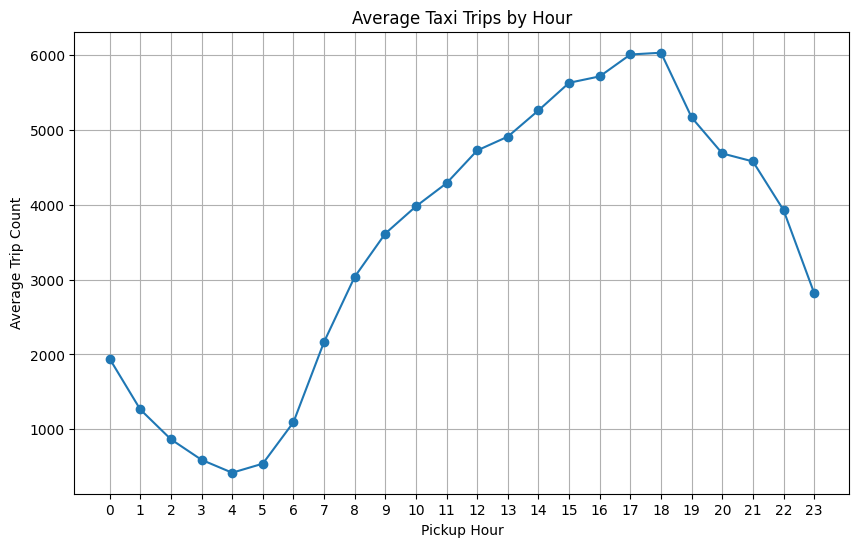

In [0]:
taxi_pd = taxi_avg_trips_by_hour.toPandas()
plt.figure(figsize=(10, 6))
plt.plot(taxi_pd["pickup_hour"], taxi_pd["average_trip_count"], marker='o')
plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Count")
plt.title("Average Taxi Trips by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [0]:
taxi_rides_by_date = clean_taxi_data.withColumn(
    "pickup_date", F.to_date("pickup_datetime_local", ISO_DATE_FORMAT)
).select(["pickup_date", "passenger_count", "total_amount", "trip_distance"])

if DEBUG:
    display(taxi_rides_by_date.limit(10))
    print(f"There are {taxi_rides_by_date.count()} taxi rides in the dataset.")

pickup_date,passenger_count,total_amount,trip_distance
2026-01-01,1,15.86,0.97
2026-01-01,4,55.56,5.58
2026-01-01,2,24.94,2.33
2026-01-01,1,17.15,1.3
2026-01-01,1,51.66,5.34
2026-01-01,3,18.06,1.83
2026-01-01,1,42.42,3.09
2026-01-01,1,21.42,1.26
2026-01-01,2,27.65,0.9
2026-01-01,3,10.15,0.33


There are 2582091 taxi rides in the dataset.


In [0]:
taxi_rides_by_day = (
    taxi_rides_by_date.groupBy("pickup_date")
    .agg(
        F.sum("passenger_count").alias("total_passengers"),
        F.round(F.sum("total_amount"), 2).alias("total_amount"),
        F.round(F.sum("trip_distance"), 2).alias("total_distance"),
        F.count("*").alias("trip_count"),
    )
    .withColumnRenamed("pickup_date", "date")
)

if DEBUG:
    display(taxi_rides_by_day.limit(10))

date,total_passengers,total_amount,total_distance,trip_count
2026-01-05,93234,2330803.03,306998.73,75012
2026-01-04,91258,2108754.92,282430.56,65567
2026-01-07,105209,2508494.07,297714.57,87556
2026-01-11,103136,2303347.56,288908.55,79029
2026-01-06,101782,2436124.42,302132.29,83762
2026-01-25,24355,469935.27,50622.12,18260
2026-01-28,103642,2803225.46,295358.18,88339
2026-01-29,112793,2984164.43,308304.24,95380
2026-01-31,115232,2313033.96,249945.62,87273
2026-01-01,98395,2007099.39,246001.11,65213


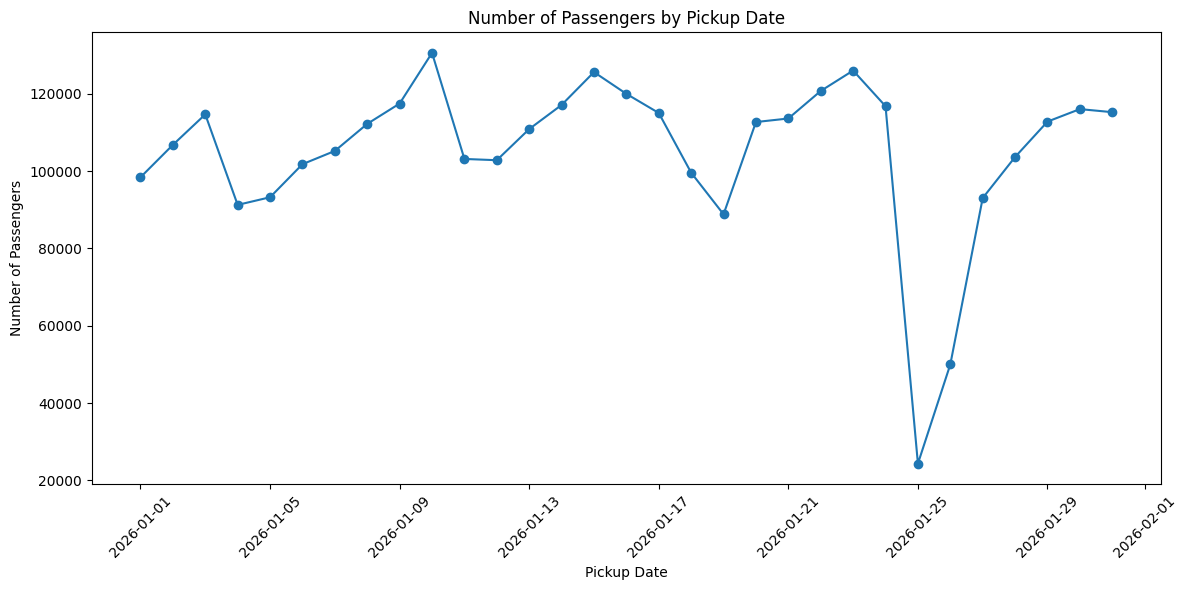

In [0]:
taxi_pd = taxi_rides_by_day.select("date", "total_passengers").orderBy("date").toPandas()
plt.figure(figsize=(12, 6))
plt.plot(taxi_pd["date"], taxi_pd["total_passengers"], marker="o")
plt.xlabel("Pickup Date")
plt.ylabel("Number of Passengers")
plt.title("Number of Passengers by Pickup Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
weather_measurement_by_day = clean_weather_data.select(
    ["date", "temp", "rhum", "prcp", "wspd", "pres", "cldc"]
)

if DEBUG:
    display(weather_measurement_by_day.limit(10))

date,temp,rhum,prcp,wspd,pres,cldc
2026-01-01,-0.8,56,0.4,13.6,1007.9,3
2026-01-02,-2.6,70,0.0,16.3,1010.4,6
2026-01-03,-1.6,54,0.0,10.0,1015.3,5
2026-01-04,0.2,64,0.0,7.2,1019.1,5
2026-01-05,1.0,73,0.0,11.5,1021.4,6
2026-01-06,3.9,87,0.0,11.5,1012.9,7
2026-01-07,6.6,82,0.0,8.2,1008.9,7
2026-01-08,8.0,67,0.0,4.6,1022.5,3
2026-01-09,8.3,94,0.0,7.5,1022.9,5
2026-01-10,6.8,87,0.1,13.1,1018.6,7


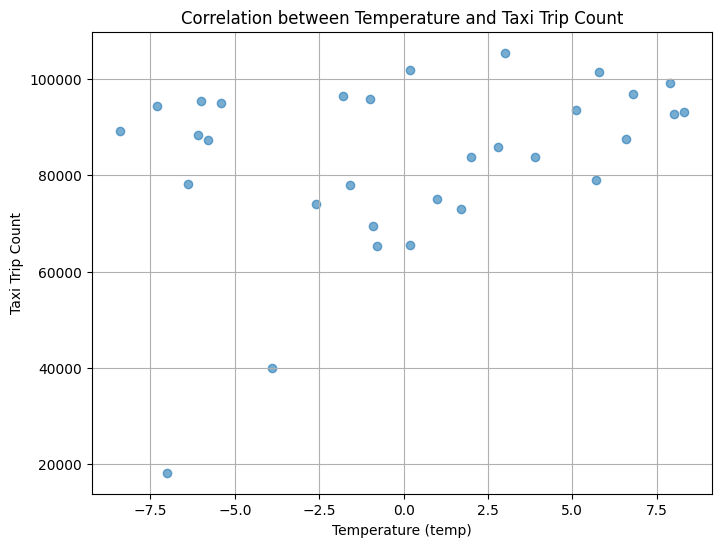

In [0]:
# Join weather and taxi data on date
weather_taxi_corr = (
    weather_measurement_by_day.select("date", "temp")
    .join(taxi_rides_by_day.select("date", "trip_count"), on="date", how="inner")
    .select("temp", "trip_count")
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(weather_taxi_corr["temp"], weather_taxi_corr["trip_count"], alpha=0.6)
plt.xlabel("Temperature (temp)")
plt.ylabel("Taxi Trip Count")
plt.title("Correlation between Temperature and Taxi Trip Count")
plt.grid(True)
plt.show()

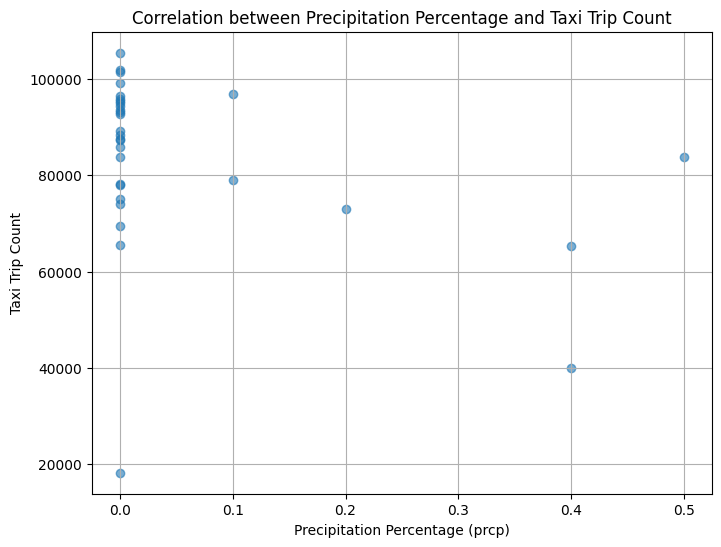

In [0]:
weather_taxi_prcp_corr = (
    weather_measurement_by_day.select("date", "prcp")
    .join(taxi_rides_by_day.select("date", "trip_count"), on="date", how="inner")
    .select("prcp", "trip_count")
    .toPandas()
)

plt.figure(figsize=(8, 6))
plt.scatter(weather_taxi_prcp_corr["prcp"], weather_taxi_prcp_corr["trip_count"], alpha=0.6)
plt.xlabel("Precipitation Percentage (prcp)")
plt.ylabel("Taxi Trip Count")
plt.title("Correlation between Precipitation Percentage and Taxi Trip Count")
plt.grid(True)
plt.show()